# Final Data Polishing before Feature Engineering

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("../data/train/data.csv")

# Remove junk columns
# df = df.drop(columns=["address"])
display(df.head())

,propertyUrl,assessmentClass,zoning,bathroomsCount,bedroomsCount,livingArea,lotSizeArea,yearBuilt,garage,houseStyle,...,L_basement2,L_exteriorConstruction1,L_extras,L_flooringType,L_foundationType,L_heating,L_roofMaterial,walkscore,transitscore,bikescore
0,https://www.honestdoor.com/property/11647-124-...,Condo Building,RA8,4.0,4.0,2068.0,697.0,1962.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.0,55.0,56.0
1,https://www.honestdoor.com/property/15116-116-...,Commercial,IH,NaN,NaN,NaN,NaN,1977.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.0,42.0,26.0
2,https://www.honestdoor.com/property/10749-181-...,Commercial,IM,NaN,NaN,NaN,NaN,2002.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,38.0,25.0
3,https://www.honestdoor.com/property/18925-ston...,Commercial,DC2,NaN,NaN,3644.0,0.0,2005.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.0,32.0,26.0
4,https://www.honestdoor.com/property/18920-100-...,Commercial,DC2,NaN,NaN,26823.0,0.0,2013.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,35.0,32.0


In [3]:
# assessmentClass strip, lower, remove all puncts
df["assessmentClass"] = df["assessmentClass"].str.strip().str.lower().str.replace(r'[^\w\s]+', '', regex=True)

# residential + other residential -> residential
df["assessmentClass"] = df["assessmentClass"].replace("other residential", "residential")

# condo + condo building -> condo
df["assessmentClass"] = df["assessmentClass"].replace("condo building", "condo")

# everything else -> other
df["assessmentClass"] = df["assessmentClass"].where(df["assessmentClass"].isin(["residential", "condo"]), "other")

display(df["assessmentClass"].value_counts())

assessmentClass
residential    5423
condo          2096
other           259
Name: count, dtype: int64

In [4]:
# houseStyle strip, lower, remove all puncts
df["houseStyle"] = df["houseStyle"].str.strip().str.lower().str.replace(r'[^\w\s]+', '', regex=True)


# 2 storey + 2storey + 2 storey split + 2 storeyattachedside by side -> 2 storey
df["houseStyle"] = df["houseStyle"].replace(["2storey", "2 storey split", "2 storeyattachedside by side"], "2 storey")

# single level apartment + multi level apartment + studio suite + penthouse + apartmentsingle level unit + loft -> apartment
df["houseStyle"] = df["houseStyle"].replace(["single level apartment", "multi level apartment", "studio suite", "penthouse", "apartmentsingle level unit", "loft"], "apartment")

# four level split + 4 level split -> 4 level split
df["houseStyle"] = df["houseStyle"].replace(["four level split", "4 level split"], "4 level split")

# raised bungalow + hillside bungalow -> raised bungalow
df["houseStyle"] = df["houseStyle"].replace(["hillside bungalow"], "raised bungalow")

# other + condo +back split + duplex + lowrise14 + vacant lot + detached + 6995 strom lane + single family detached -> other
df["houseStyle"] = df["houseStyle"].replace(["other", "condo", "back split", "duplex", "lowrise14", "vacant lot", "detached", "6995 strom lane", "single family detached"], "other")

display(df["houseStyle"].value_counts())

houseStyle
2 storey             2111
bungalow             1197
apartment             670
bilevel               247
4 level split         210
other                  87
1 and half storey      78
3 storey               71
raised bungalow        53
2 and half storey      24
5 level split          17
3 level split          10
Name: count, dtype: int64

In [5]:
# basement strip, lower, remove all puncts
df["basement"] = df["basement"].str.strip().str.lower().str.replace(r'[^\w\s]+', '', regex=True)

# finished + fully finished -> finished
df["basement"] = df["basement"].replace(["fully finished"], "finished")

# partially finished + partly finished -> partially finished
df["basement"] = df["basement"].replace(["partly finished"], "partially finished")

display(df["basement"].value_counts())


basement
finished              645
unfinished            330
partially finished    122
no basement            13
Name: count, dtype: int64

In [6]:
# L_basement1

# Full Fully Finished -> Full, Finished
df["L_basement1"] = df["L_basement1"].replace(["Full Fully Finished"], "Full, Finished")

# None Unfinished -> None, Finished
df["L_basement1"] = df["L_basement1"].replace(["None Unfinished"], "None, Finished")

# Full,Unfinished + Finished,Full -> Full, Finished
df["L_basement1"] = df["L_basement1"].replace(["Full,Unfinished", "Finished,Full"], "Full, Finished")

# Full,Separate/Exterior Entry,Suite -> Full, See Remarks
df["L_basement1"] = df["L_basement1"].replace(["Full,Separate/Exterior Entry,Suite"], "Full, See Remarks")

# See Remarks -> See Remarks, See Remarks
df["L_basement1"] = df["L_basement1"].replace(["See Remarks"], "See Remarks, See Remarks")

# Split into size and status
df[["L_basement1_size", "L_basement1_status"]] = (
    df["L_basement1"]
    .str.split(",", n=1, expand=True)
)

# Remove leading/trailing spaces
for col in ["L_basement1_size", "L_basement1_status"]:
    df[col] = df[col].str.strip().replace("See Remarks", "Other")

df = df.drop(columns=["L_basement1"], errors="ignore")

In [7]:
# L_basement2

# See Remarks -> Other
df["L_basement2"] = df["L_basement2"].replace(["See Remarks"], "Other")


df.rename(columns={"L_basement2": "L_basement2_status"}, inplace=True)

# Multi-Component Features

In [8]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt


def plot_multilabel_frequency(
    df,
    column,
    delimiter=",",
    min_pct=None,
    figsize=(12, 6),
):
    """
    Plot percentage frequency of values in a multi-label column.

    Parameters
    ----------
    df : pd.DataFrame
    column : str
        Column containing values like 'Wood, Vinyl'
    delimiter : str
    min_pct : float or None
        Filter categories below this percentage.
    figsize : tuple
    """

    counts = Counter()

    for value in df[column].dropna():
        labels = [x.strip() for x in str(value).split(delimiter)]
        counts.update(labels)

    freq_df = (
        pd.DataFrame(
            counts.items(),
            columns=["label", "count"]
        )
        .sort_values("count", ascending=False)
    )

    n = df[column].notna().sum()

    freq_df["pct"] = freq_df["count"] / n * 100

    if min_pct is not None:
        freq_df = freq_df[freq_df["pct"] >= min_pct]

    display(freq_df[["label", "pct"]])

    plt.figure(figsize=figsize)
    plt.bar(freq_df["label"], freq_df["pct"])
    plt.xticks(rotation=90)
    plt.ylabel("% of Properties")
    plt.xlabel(column)
    plt.title(f"{column} Frequency (%)")
    plt.tight_layout()
    plt.show()

    return freq_df

def clean_exterior_materials(value, keep_materials):
    if pd.isna(value):
        return value

    materials = [m.strip() for m in value.split(",")]
    # print(materials,keep_materials)
    cleaned = [
        m if m in keep_materials else "Other"
        for m in materials
    ]

    # Remove duplicate "Other" entries
    cleaned = list(dict.fromkeys(cleaned))

    return ", ".join(cleaned)

def multi_hot_encode(train, column, values, prefix):
    values.add("Other")
    col_names = [column]
    for value in values:
        col_name = f"{prefix}{value.replace(" ", "_")}"

        train[col_name] = (
            train[column]
            .fillna("")
            .apply(lambda x: int(value in [v.strip() for v in x.split(",")]))
        )
    display(train[col_names].sample(10))

    return train

,label,pct
0,Wood,95.737352
1,Vinyl,62.604952
4,Stucco,32.077503
2,Brick,16.297094
6,Stone,14.790097
5,Concrete,4.155005
3,Metal,3.659849
7,Hardie Board Siding,1.700753


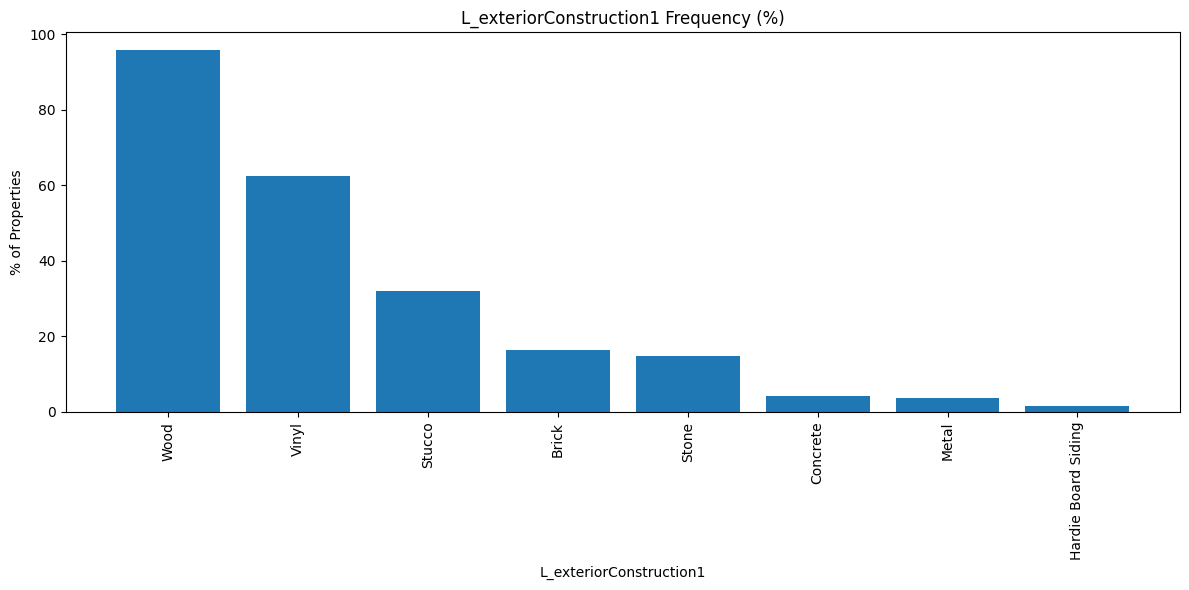

In [9]:
# L_exteriorConstruction1
material_df = plot_multilabel_frequency(
    df,
    "L_exteriorConstruction1",
    min_pct=1
)

In [10]:
KEEP_EXTERIORS = {
    "Wood",
    "Vinyl",
    "Stucco",
    "Brick",
    "Stone",
    "Concrete",
    "Metal",
}

df["L_exteriorConstruction1"] = (
    df["L_exteriorConstruction1"]
    .apply(lambda x: clean_exterior_materials(x, KEEP_EXTERIORS))
)

In [11]:
df = multi_hot_encode(
    df,
    column="L_exteriorConstruction1",
    values=KEEP_EXTERIORS,
    prefix="exterior"
)

df.drop(columns=["L_exteriorConstruction1"], inplace=True)

,L_exteriorConstruction1
643,NaN
729,"Wood, Vinyl"
7020,"Wood, Vinyl"
2164,"Wood, Vinyl"
6293,"Wood, Stone, Vinyl"
6481,"Wood, Stucco"
4612,"Wood, Brick, Vinyl"
2990,"Wood, Vinyl"
5046,"Wood, Other"
2315,Wood


,label,pct
0,Carpet,66.530612
4,Ceramic Tile,43.179377
1,Hardwood,33.404941
5,Laminate Flooring,32.094522
3,Vinyl Plank,27.411386
2,Linoleum,20.945220
6,Non-Ceramic Tile,2.986037
7,Engineered Wood,2.878625
10,Wall to Wall Carpet,1.203008
12,See Remarks,1.181525


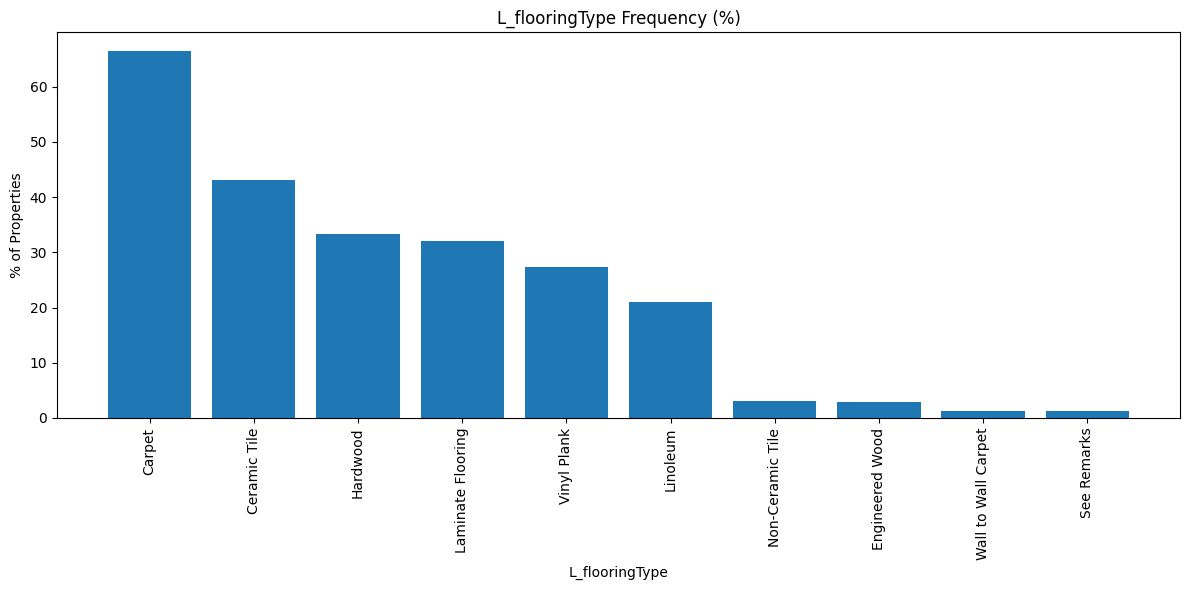

In [12]:
# L_flooringType
flooringType_df = plot_multilabel_frequency(
    df,
    "L_flooringType",
    min_pct=1
)

In [13]:
KEEP_FLOORTYPE = {
    "Carpet",
    "Ceramic Tile",
    "Hardwood",
    "Laminate Flooring",
    "Linoleum"
}

df["L_flooringType"] = (
    df["L_flooringType"]
    .apply(lambda x: clean_exterior_materials(x, KEEP_FLOORTYPE))
)


In [14]:
df = multi_hot_encode(
    df,
    column="L_flooringType",
    values=KEEP_FLOORTYPE,
    prefix="floor"
)

df.drop(columns=["L_flooringType"], inplace=True)

,L_flooringType
1572,NaN
6485,"Carpet, Linoleum"
635,NaN
7505,NaN
3756,"Carpet, Ceramic Tile, Other"
2077,NaN
3187,NaN
2005,"Laminate Flooring, Linoleum"
2644,NaN
1611,"Ceramic Tile, Laminate Flooring"


,label,pct
0,Concrete Perimeter,96.984059
1,Slab,1.594140


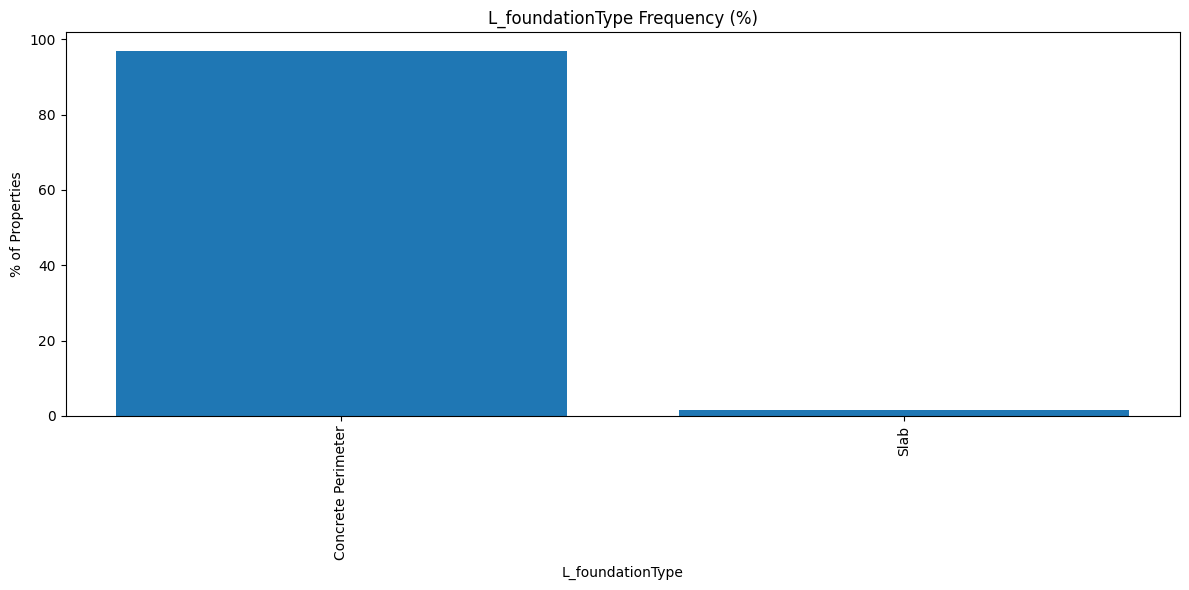

In [15]:
# L_foundationType
foundationType_df = plot_multilabel_frequency(
    df,
    "L_foundationType",
    min_pct=1
)

In [16]:
def keep_concrete_perimeter(value):
    if pd.isna(value):
        return np.nan

    materials = [x.strip() for x in str(value).split(",")]

    if "Concrete Perimeter" in materials:
        return "Concrete Perimeter"

    return np.nan

df["L_foundationType"] = df["L_foundationType"].apply(keep_concrete_perimeter)

In [17]:
df = multi_hot_encode(
    df,
    column="L_foundationType",
    values={"Concrete Perimeter"},
    prefix="foundation"
)

df.drop(columns=["L_foundationType","floorOther"], inplace=True)

,L_foundationType
2016,Concrete Perimeter
905,Concrete Perimeter
1190,NaN
6851,Concrete Perimeter
6571,NaN
1671,NaN
7708,Concrete Perimeter
4587,NaN
4003,Concrete Perimeter
5696,Concrete Perimeter


,label,pct
1,Natural Gas,97.250269
0,Forced Air-1,80.300752
2,Baseboard,8.206230
3,Forced Air-2,6.079484
5,Hot Water,5.864662
6,Water,1.761547
7,In Floor Heat System,1.417830


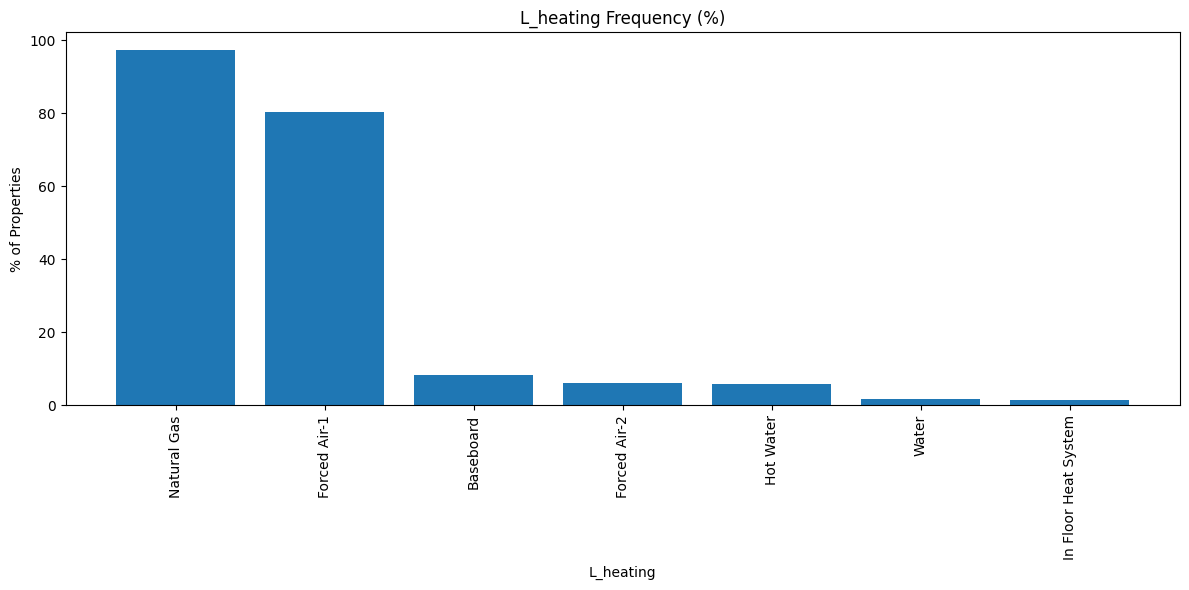

In [18]:
# L_heating
material_df = plot_multilabel_frequency(
    df,
    "L_heating",
    min_pct=1
)

In [19]:
KEEP_HEATING = {
    "Natural Gas",
    "Forced Air-1",
}

df["L_heating"] = (
    df["L_heating"]
    .apply(lambda x: clean_exterior_materials(x, KEEP_HEATING))
)

In [20]:
df = multi_hot_encode(
    df,
    column="L_heating",
    values=KEEP_HEATING,
    prefix="heat"
)

df.drop(columns=["L_heating"], inplace=True)

,L_heating
1655,"Forced Air-1, Natural Gas"
6511,"Forced Air-1, Natural Gas"
5574,NaN
7655,NaN
5706,NaN
5441,NaN
7036,NaN
6548,NaN
2118,"Forced Air-1, Natural Gas"
6968,NaN


,label,pct
0,Asphalt Shingles,89.039621
1,Tar &amp; Gravel,5.232558
10,Cedar Shakes,1.248923


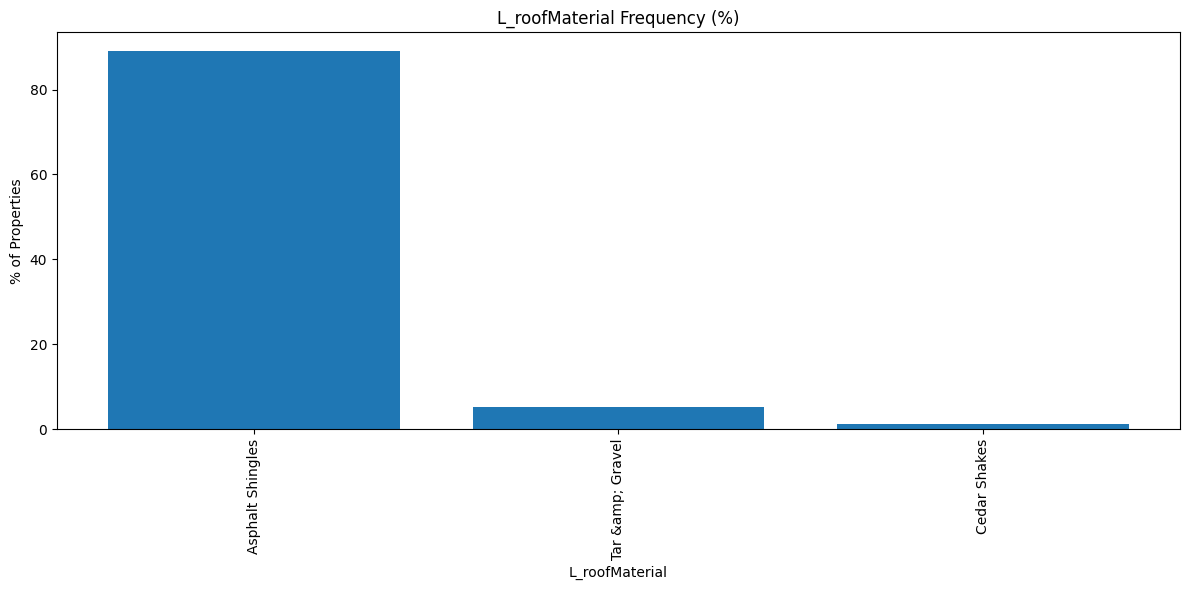

In [21]:
# L_roofMaterial

roofMaterial_df = plot_multilabel_frequency(
    df,
    "L_roofMaterial",
    min_pct=1
)

In [22]:
KEEP_ROOFMATERIALS = {
    "Asphalt Shingles",
}

df["L_roofMaterial"] = (
    df["L_roofMaterial"]
    .apply(lambda x: clean_exterior_materials(x, KEEP_ROOFMATERIALS))
)

In [23]:
df = multi_hot_encode(
    df,
    column="L_roofMaterial",
    values=KEEP_ROOFMATERIALS,
    prefix="roof"
)

df.drop(columns=["L_roofMaterial"], inplace=True)

,L_roofMaterial
4802,"Asphalt Shingles, Other"
3191,Asphalt Shingles
5892,NaN
135,NaN
4749,Asphalt Shingles
1689,NaN
1577,NaN
1169,NaN
1227,NaN
6059,Asphalt Shingles


,label,pct
3,Refrigerator,83.015598
11,Dryer,82.084055
13,Washer,81.520797
0,Dishwasher-Built-In,79.787695
12,Stove-Electric,74.891681
6,Window Coverings,52.448007
1,Garage Opener,41.724437
14,Hood Fan,36.720104
24,Garage Control,35.528596
2,Microwave Hood Fan,33.102253


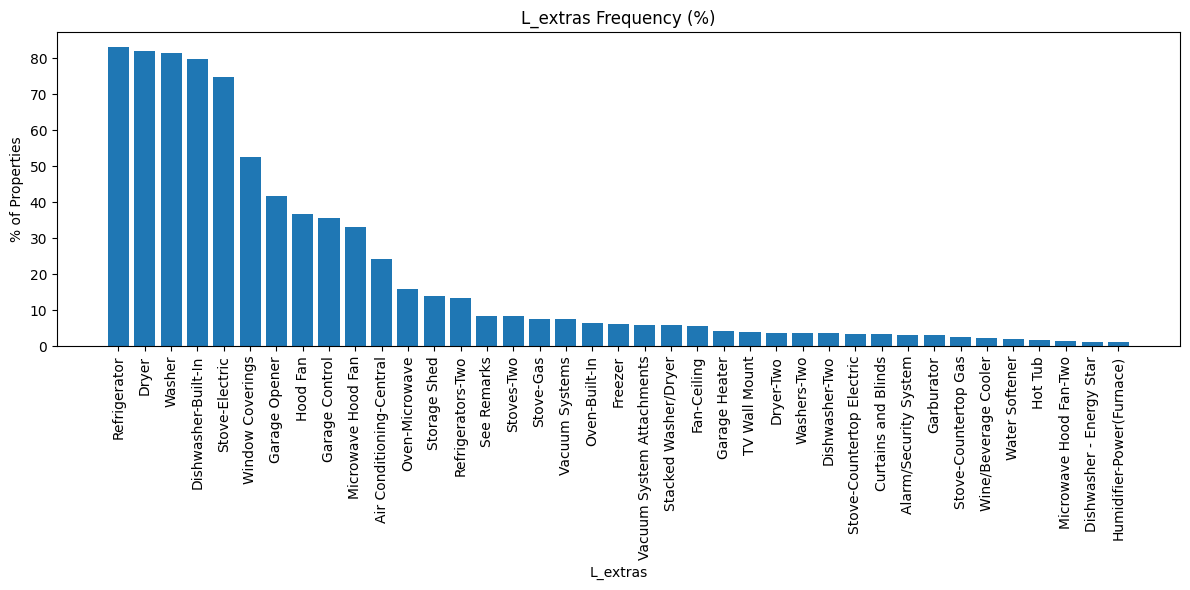

In [24]:
# L_extras

estras_df = plot_multilabel_frequency(
    df,
    "L_extras",
    min_pct=1
)

In [25]:
KEEP_EXTRAS = {
    "Refrigerator",
    "Dishwasher-Built-In",
    "Dryer",
    "Washer",
    "Stove-Electric",
    "Window Coverings",
    "Garage Opener",
    "Hood Fan",
    "Garage Control",
    "Microwave Hood Fan",
    "Air Conditioning-Central",
}

df["L_extras"] = (
    df["L_extras"]
    .apply(lambda x: clean_exterior_materials(x, KEEP_EXTRAS))
)


In [26]:
df = multi_hot_encode(
    df,
    column="L_extras",
    values=KEEP_EXTRAS,
    prefix="extra"
)

df.drop(columns=["L_extras"], inplace=True)

,L_extras
6042,"Air Conditioning-Central, Dishwasher-Built-In,..."
4426,"Dishwasher-Built-In, Dryer, Microwave Hood Fan..."
2355,"Dryer, Refrigerator, Other, Stove-Electric, Wa..."
1464,NaN
4068,NaN
6269,"Dishwasher-Built-In, Dryer, Other, Refrigerato..."
4610,"Dishwasher-Built-In, Dryer, Garage Control, Ga..."
4450,NaN
2382,"Dishwasher-Built-In, Dryer, Garage Control, Ga..."
3116,Other


In [27]:
df.head(5)

,propertyUrl,assessmentClass,zoning,bathroomsCount,bedroomsCount,livingArea,lotSizeArea,yearBuilt,garage,houseStyle,...,extraOther,extraDryer,extraGarage_Opener,extraStove-Electric,extraRefrigerator,extraHood_Fan,extraAir_Conditioning-Central,extraWasher,extraMicrowave_Hood_Fan,extraDishwasher-Built-In
0,https://www.honestdoor.com/property/11647-124-...,condo,RA8,4.0,4.0,2068.0,697.0,1962.0,0.0,NaN,...,0,0,0,0,0,0,0,0,0,0
1,https://www.honestdoor.com/property/15116-116-...,other,IH,NaN,NaN,NaN,NaN,1977.0,0.0,NaN,...,0,0,0,0,0,0,0,0,0,0
2,https://www.honestdoor.com/property/10749-181-...,other,IM,NaN,NaN,NaN,NaN,2002.0,0.0,NaN,...,0,0,0,0,0,0,0,0,0,0
3,https://www.honestdoor.com/property/18925-ston...,other,DC2,NaN,NaN,3644.0,0.0,2005.0,0.0,NaN,...,0,0,0,0,0,0,0,0,0,0
4,https://www.honestdoor.com/property/18920-100-...,other,DC2,NaN,NaN,26823.0,0.0,2013.0,0.0,NaN,...,0,0,0,0,0,0,0,0,0,0


,label,pct
5,RF1,32.037585
9,RA7,13.180590
10,RSL,10.915176
11,RF5,9.190372
8,RF4,6.564551
6,RF3,6.165530
7,RPL,4.479341
0,RA8,2.600077
3,DC2,2.098082
23,DC1,1.917879


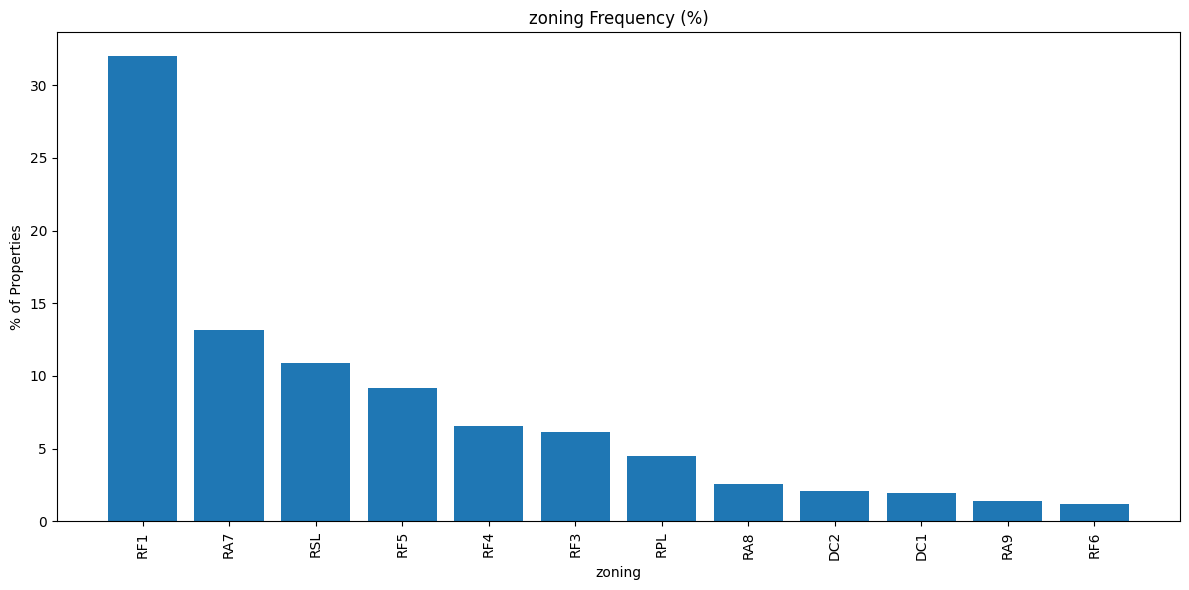

In [28]:
# zoning

zoning_df = plot_multilabel_frequency(
    df,
    "zoning",
    min_pct=1
)

# Closed Date

In [29]:
df["closeDate"] = pd.to_datetime(df["closeDate"], utc=True)

reference_date = pd.Timestamp("2000-01-01", tz="UTC")

# days since 2000 
df["closeDate_days"] = (
    df["closeDate"] - reference_date
).dt.days

df.drop(columns=["closeDate"], inplace=True)

In [30]:
# save the cleaned data
df.to_csv("../data/train/data_clean.csv", index=False)